# 12 · Liquid-liquid equilibria and polymer solutions

Oil and water separate; so do butanol and water beyond a few percent - and so, under the right conditions,
do polymer solutions and blends. Two liquid phases form when mixing lowers the Gibbs energy less than
staying apart would: the same activity coefficients that bend a T-x-y diagram, if large enough, split the
liquid. This notebook computes miscibility gaps from activity models and Flory-Huggins theory, the
foundation of polymer solution thermodynamics.

**What you will learn**
- explain liquid-liquid splitting from the Gibbs energy of mixing
- compute binary LLE from activity coefficients
- estimate extraction distribution coefficients
- use Flory-Huggins theory for polymer solutions and their phase diagrams

**Before you start:** notebooks 09-10  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, lle, unifac
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## When does a liquid split? The Gibbs energy of mixing

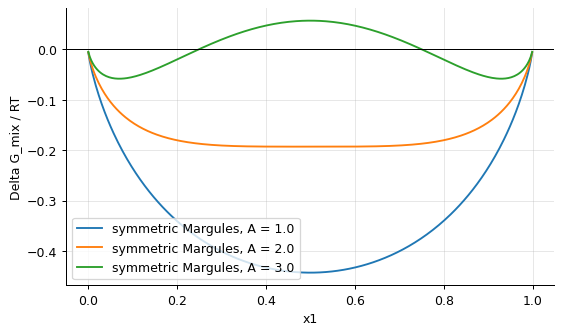

A = 1.5: completely miscible
A = 2.5: two phases with x1 = 0.145 and 0.855
A = 3.0: two phases with x1 = 0.071 and 0.929


In [2]:
x = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots()
for A in (1.0, 2.0, 3.0):
    ax.plot(x, lle.gibbs_of_mixing(activity.margules(A), x, 300.0), label=f"symmetric Margules, A = {A}")
ax.axhline(0, color="k", lw=0.8); ax.set(xlabel="x1", ylabel="Delta G_mix / RT"); ax.legend(); plt.show()
for A in (1.5, 2.5, 3.0):
    r = lle.binary(activity.margules(A), 300.0)
    print(f"A = {A}: " + ("completely miscible" if r is None else f"two phases with x1 = {r['x1_alpha']:.3f} and {r['x1_beta']:.3f}"))

For weak non-ideality the curve is convex everywhere: any mixture has a lower Gibbs energy than any two
phases it could split into. Above a critical value ($A$ = 2 for the symmetric model) the curve develops a
hump, and a common tangent touches two compositions: the mixture splits into those two phases, with the
same chemical potential (activity) of each component in both.

## Butanol-water predicted by UNIFAC

In [3]:
g_bw = unifac.gamma_function(["1-butanol", "water"])
for T_C in (25, 60, 90):
    r = lle.binary(g_bw, T_C + 273.15)
    print(f"{T_C} degC: butanol-rich phase x_butanol = {r['x1_beta']:.3f}, water-rich phase x_butanol = {r['x1_alpha']:.4f}")
print("experimental at 25 degC: about 0.50 and 0.019 (7.8 wt % butanol in the aqueous phase)")

25 degC: butanol-rich phase x_butanol = 0.482, water-rich phase x_butanol = 0.0196
60 degC: butanol-rich phase x_butanol = 0.467, water-rich phase x_butanol = 0.0254
90 degC: butanol-rich phase x_butanol = 0.452, water-rich phase x_butanol = 0.0308
experimental at 25 degC: about 0.50 and 0.019 (7.8 wt % butanol in the aqueous phase)


UNIFAC, parameterised on vapour-liquid data, predicts both phases of this system within about 5 % - and the
widening of the miscibility gap's water-rich branch with temperature. Such agreement is not guaranteed:
the water-rich branch is controlled by the very large activity coefficient of butanol at infinite dilution,
which VLE-based parameters often get wrong by tens of percent. For design, liquid-liquid equilibria are fitted
with NRTL or UNIQUAC parameters from LLE data themselves; UNIFAC is the screening tool.

## Extraction: the distribution coefficient

In [4]:
ginf_w = activity.infinite_dilution(unifac.gamma_function(["acetone", "water"]), 298.15)[0]
for solvent in ("1-butanol", "ethyl acetate", "toluene"):
    ginf_s = activity.infinite_dilution(unifac.gamma_function(["acetone", solvent]), 298.15)[0]
    print(f"acetone from water into {solvent:<14}: distribution coefficient (mole-fraction basis) about {ginf_w/ginf_s:.1f}")

acetone from water into 1-butanol     : distribution coefficient (mole-fraction basis) about 5.6
acetone from water into ethyl acetate : distribution coefficient (mole-fraction basis) about 8.8
acetone from water into toluene       : distribution coefficient (mole-fraction basis) about 7.8


At low solute concentration the distribution coefficient between two immiscible solvents is the ratio of the
solute's infinite-dilution activity coefficients, $K = \gamma^\infty_{water}/\gamma^\infty_{solvent}$. A large $K$ means a
small solvent flow in the extractor - the first number an extraction design needs.

## Polymer solutions: Flory-Huggins theory
A polymer chain of $N$ segments on a lattice mixes with solvent with a tiny entropy (the segments cannot move
independently) and an interaction energy $\chi$ per contact:
$\Delta G/RT = (1-\phi)\ln(1-\phi) + (\phi/N)\ln\phi + \chi\phi(1-\phi)$. Because the entropy is so small,
even a mild unfavourable $\chi$ splits the solution:

N =    1: critical chi = 2.000 at polymer volume fraction 0.500
N =   10: critical chi = 0.866 at polymer volume fraction 0.240
N =  100: critical chi = 0.605 at polymer volume fraction 0.091


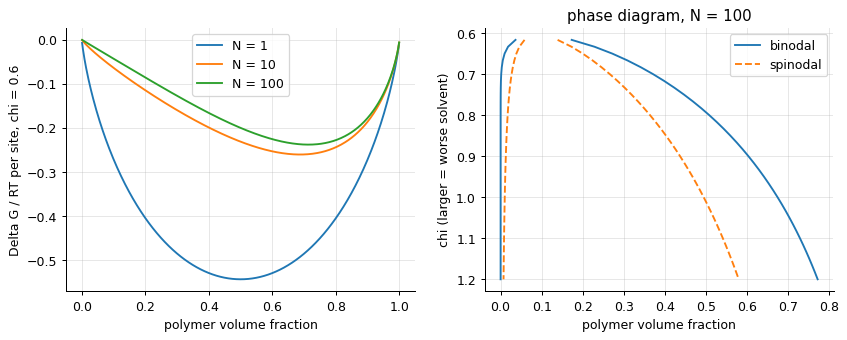

In [5]:
phi = np.linspace(0.001, 0.999, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for N in (1, 10, 100):
    crit = lle.flory_huggins_critical(N)
    a1.plot(phi, lle.flory_huggins_gibbs(phi, 0.6, N), label=f"N = {N}")
    print(f"N = {N:4d}: critical chi = {crit['chi_c']:.3f} at polymer volume fraction {crit['phi_c']:.3f}")
a1.set(xlabel="polymer volume fraction", ylabel="Delta G / RT per site, chi = 0.6"); a1.legend()
chis = np.linspace(0.55, 1.2, 40)
N = 100
bin_lo, bin_hi, sp = [], [], []
for c in chis:
    b = lle.flory_huggins_binodal(c, N)
    bin_lo.append(b["phi_dilute"] if b else np.nan); bin_hi.append(b["phi_concentrated"] if b else np.nan)
    s = lle.flory_huggins_spinodal(c, N); sp.append(s if s.size else [np.nan, np.nan])
sp = np.array(sp)
a2.plot(bin_lo, chis, "C0", label="binodal"); a2.plot(bin_hi, chis, "C0"); a2.plot(sp[:, 0], chis, "C1--", label="spinodal"); a2.plot(sp[:, 1], chis, "C1--")
a2.invert_yaxis(); a2.set(xlabel="polymer volume fraction", ylabel="chi (larger = worse solvent)", title=f"phase diagram, N = {N}"); a2.legend(); plt.show()

Two features distinguish polymers from small molecules: the critical $\chi$ falls towards 0.5 as the chains
lengthen (a solvent that is marginal for the monomer is a non-solvent for the polymer), and the phase diagram
is strongly asymmetric - the dilute phase contains almost no polymer while the concentrated phase is a gel.
Between the binodal and the spinodal the solution is metastable; inside the spinodal it decomposes
spontaneously - the mechanism behind many porous membranes and polymer foams.

## Temperature: the upper critical solution temperature
With $\chi = A + B/T$, the polymer dissolves on heating and precipitates on cooling below the UCST:

In [6]:
A, B = 0.20, 90.0                                     # an illustrative polystyrene-cyclohexane-like system (theta temperature ~ 300 K)
for N in (100, 1000, 10000):
    print(f"N = {N:5d}: UCST = {lle.ucst(A, B, N):.1f} K; theta temperature (chi = 0.5, infinite N) = {B/(0.5 - A):.1f} K")

N =   100: UCST = 222.2 K; theta temperature (chi = 0.5, infinite N) = 300.0 K
N =  1000: UCST = 271.0 K; theta temperature (chi = 0.5, infinite N) = 300.0 K
N = 10000: UCST = 290.3 K; theta temperature (chi = 0.5, infinite N) = 300.0 K


The UCST rises with molar mass towards the theta temperature - which is why fractionating a polymer by
molar mass works (cooling precipitates the longest chains first), and why polymer blends of high molar mass
almost never mix: with two long chains, even the small entropy of mixing of a polymer solution is gone.

## Inside the algorithm: the isoactivity equations
The two phases have equal activities of both components: $x_1^\alpha\gamma_1^\alpha = x_1^\beta\gamma_1^\beta$ and likewise for component 2.
Solve the two equations with `scipy.optimize.root`:

In [7]:
from scipy import optimize
g = activity.margules(2.5)
def eqs(v):
    a, b = v
    ga, gb = g([a, 1 - a]), g([b, 1 - b])
    return [np.log(a * ga[0]) - np.log(b * gb[0]), np.log((1 - a) * ga[1]) - np.log((1 - b) * gb[1])]
sol = optimize.root(eqs, [0.1, 0.9])
print("by hand:", np.round(sorted(sol.x), 5), " library:", [round(v, 5) for v in lle.binary(g, 300.0).values() if isinstance(v, float)][:2])

by hand: [0.14479 0.85521]  library: [0.14479, 0.85521]


## Exercises
1. Hexane-ethanol: with UNIFAC, find the temperature below which the liquid splits (the upper critical solution temperature). Scan `lle.binary` from 60 degC downwards.
2. For the illustrative polymer solution (chi = 0.20 + 90/T), plot the cloud-point (UCST) temperature against molar mass for N = 50 to 50 000 on a log axis. What does this imply for polymer fractionation by cooling?
3. **Implement it yourself:** derive the Flory-Huggins spinodal condition $\partial^2(\Delta G/RT)/\partial\phi^2 = 0$ by differentiating the Gibbs energy numerically, and reproduce `lle.flory_huggins_spinodal(0.7, 100)`.